# Required Capstone Assignment 20.1: Initial Report and EDA

## Ecommerce Revenue, Retention, and Customer Experience Optimization

This notebook performs the Module 20 exploratory data analysis for the Olist ecommerce capstone project and compares multiple machine learning models for predicting low customer satisfaction risk.

**Primary modeling target:** predict low customer satisfaction risk, defined as an order review score of 1 or 2.

**Why this target:** review score is available in the Olist dataset, directly relates to customer experience, and can be translated into operational actions such as delivery improvement, proactive support, and retention campaigns.

## Rubric Coverage

| Rubric area | Where it is addressed |
|---|---|
| Project organization | README summary and notebook link; organized folders for data, outputs, and notebooks |
| Syntax and code quality | Clean imports, functions, pandas joins/grouping, readable variable names |
| Visualizations | Revenue, categories, geography, review scores, delivery, outliers, ROC curve, confusion matrix |
| Data cleaning and EDA | Missing values, duplicates, date parsing, feature engineering, outlier analysis |
| Modeling | Logistic regression baseline plus random forest and gradient boosting comparison with ROC-AUC, precision, recall, F1, and confusion matrix |

## 1. Import Libraries

In [153]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.linear_model._linear_loss")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils._plotting")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 2. Load Raw Data

The Olist dataset is relational, so the analysis begins by loading each CSV table separately.

In [154]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
translations = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {
    "customers": customers,
    "orders": orders,
    "order_items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": translations,
}

## 3. Initial Data Structure Review

In [155]:
shape_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_rows": df.duplicated().sum(),
        }
        for name, df in tables.items()
    ]
)
shape_summary

,table,rows,columns,duplicate_rows
0,customers,99441,5,0
1,orders,99441,8,0
2,order_items,112650,7,0
3,payments,103886,5,0
4,reviews,99224,7,0
5,products,32951,9,0
6,sellers,3095,4,0
7,geolocation,1000163,5,261831
8,category_translation,71,2,0


In [156]:
missing_summary = pd.DataFrame(
    [
        {
            "table": name,
            "missing_cells": int(df.isna().sum().sum()),
            "missing_cell_rate": df.isna().sum().sum() / df.size,
            "columns_with_missing": int((df.isna().sum() > 0).sum()),
        }
        for name, df in tables.items()
    ]
)
missing_summary

,table,missing_cells,missing_cell_rate,columns_with_missing
0,customers,0,0.00,0
1,orders,4908,0.01,3
2,order_items,0,0.00,0
3,payments,0,0.00,0
4,reviews,145903,0.21,2
5,products,2448,0.01,8
6,sellers,0,0.00,0
7,geolocation,0,0.00,0
8,category_translation,0,0.00,0


## 4. Data Cleaning and Feature Engineering

Cleaning steps:

- Convert order timestamp columns to datetime.
- Translate product categories into English.
- Aggregate line-item data to the order level.
- Aggregate payment and review data to the order level.
- Merge all analytical fields into a master order-level table.
- Create delivery, revenue, date, satisfaction, and repeat-purchase features.

In [157]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

products = products.merge(translations, on="product_category_name", how="left")
products["category"] = products["product_category_name_english"].fillna(products["product_category_name"])
products["product_volume_cm3"] = (
    products["product_length_cm"]
    * products["product_height_cm"]
    * products["product_width_cm"]
)

item_detail = items.merge(
    products[["product_id", "category", "product_weight_g", "product_volume_cm3"]],
    on="product_id",
    how="left",
).merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")

primary_category = (
    item_detail.groupby(["order_id", "category"])
    .size()
    .reset_index(name="category_count")
    .sort_values(["order_id", "category_count"], ascending=[True, False])
    .drop_duplicates("order_id")[["order_id", "category"]]
    .rename(columns={"category": "primary_category"})
)

order_items = (
    item_detail.groupby("order_id")
    .agg(
        item_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count"),
        seller_count=("seller_id", "nunique"),
        avg_product_weight_g=("product_weight_g", "mean"),
        avg_product_volume_cm3=("product_volume_cm3", "mean"),
    )
    .reset_index()
    .merge(primary_category, on="order_id", how="left")
)

order_payments = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_types=("payment_type", "nunique"),
        primary_payment_type=("payment_type", lambda x: x.mode().iat[0] if not x.mode().empty else None),
    )
    .reset_index()
)

order_reviews = reviews.groupby("order_id").agg(review_score=("review_score", "mean")).reset_index()

master = (
    orders.merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(order_payments, on="order_id", how="left")
    .merge(order_reviews, on="order_id", how="left")
)

master["delivery_days"] = (master["order_delivered_customer_date"] - master["order_purchase_timestamp"]).dt.days
master["estimated_delivery_days"] = (master["order_estimated_delivery_date"] - master["order_purchase_timestamp"]).dt.days
master["approval_hours"] = (master["order_approved_at"] - master["order_purchase_timestamp"]).dt.total_seconds() / 3600
master["delivered_late"] = master["order_delivered_customer_date"] > master["order_estimated_delivery_date"]
master["purchase_month"] = master["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
master["purchase_month_num"] = master["order_purchase_timestamp"].dt.month
master["purchase_dayofweek"] = master["order_purchase_timestamp"].dt.dayofweek
master["low_review"] = master["review_score"].le(2)

delivered = master[master["order_status"].eq("delivered")].copy()
model_data = delivered.dropna(subset=["review_score"]).copy()

preview_columns = [
    "order_id",
    "order_status",
    "customer_state",
    "item_revenue",
    "freight_value",
    "delivery_days",
    "delivered_late",
    "primary_category",
    "primary_payment_type",
    "review_score",
    "low_review",
]
master[preview_columns].head()

,order_id,order_status,customer_state,item_revenue,freight_value,delivery_days,delivered_late,primary_category,primary_payment_type,review_score,low_review
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,29.99,8.72,8.00,False,housewares,voucher,4.00,False
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,118.70,22.76,13.00,False,perfumery,boleto,4.00,False
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,159.90,19.22,9.00,False,auto,credit_card,5.00,False
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,45.00,27.20,13.00,False,pet_shop,credit_card,5.00,False
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,19.90,8.72,2.00,False,stationery,credit_card,5.00,False


## 5. Cleaned Dataset Quality Check

In [158]:
cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "Total raw orders",
            "Delivered orders",
            "Orders with review score for modeling",
            "Duplicate order IDs in master table",
            "Rows with missing delivery_days",
            "Rows with missing primary_category",
            "Rows with missing item_revenue",
        ],
        "value": [
            orders["order_id"].nunique(),
            delivered["order_id"].nunique(),
            model_data["order_id"].nunique(),
            master["order_id"].duplicated().sum(),
            int(master["delivery_days"].isna().sum()),
            int(master["primary_category"].isna().sum()),
            int(master["item_revenue"].isna().sum()),
        ],
    }
)
cleaning_summary

,metric,value
0,Total raw orders,99441
1,Delivered orders,96478
2,Orders with review score for modeling,95832
3,Duplicate order IDs in master table,0
4,Rows with missing delivery_days,2965
5,Rows with missing primary_category,2164
6,Rows with missing item_revenue,775


In [159]:
master_missing = master.isna().mean().sort_values(ascending=False).head(12).reset_index()
master_missing.columns = ["field", "missing_rate"]
master_missing

,field,missing_rate
0,delivery_days,0.03
1,order_delivered_customer_date,0.03
2,primary_category,0.02
3,order_delivered_carrier_date,0.02
4,avg_product_volume_cm3,0.01
5,avg_product_weight_g,0.01
6,item_revenue,0.01
7,freight_value,0.01
8,item_count,0.01
9,seller_count,0.01


## 6. Executive Summary Metrics

In [160]:
repeat_counts = delivered.groupby("customer_unique_id")["order_id"].nunique()
review_by_late = delivered.dropna(subset=["review_score"]).groupby("delivered_late")["review_score"].mean()

executive_metrics = pd.DataFrame(
    {
        "metric": [
            "Order date coverage start",
            "Order date coverage end",
            "Delivered order rate",
            "Unique customers",
            "Repeat customer rate",
            "Delivered item revenue",
            "Average delivered order value",
            "Median delivered order value",
            "Late delivery rate",
            "Low review rate, score <= 2",
            "Avg review score, on-time/early",
            "Avg review score, late",
        ],
        "value": [
            orders["order_purchase_timestamp"].min().date(),
            orders["order_purchase_timestamp"].max().date(),
            delivered["order_id"].nunique() / orders["order_id"].nunique(),
            customers["customer_unique_id"].nunique(),
            (repeat_counts > 1).mean(),
            delivered["item_revenue"].sum(),
            delivered["item_revenue"].mean(),
            delivered["item_revenue"].median(),
            delivered["delivered_late"].mean(),
            model_data["low_review"].mean(),
            review_by_late.loc[False],
            review_by_late.loc[True],
        ],
    }
)
executive_metrics

,metric,value
0,Order date coverage start,2016-09-04
1,Order date coverage end,2018-10-17
2,Delivered order rate,0.97
3,Unique customers,96096
4,Repeat customer rate,0.03
5,Delivered item revenue,"13,221,498.11"
6,Average delivered order value,137.04
7,Median delivered order value,86.57
8,Late delivery rate,0.08
9,"Low review rate, score <= 2",0.13


## 7. Univariate EDA: Target, Revenue, and Delivery Variables

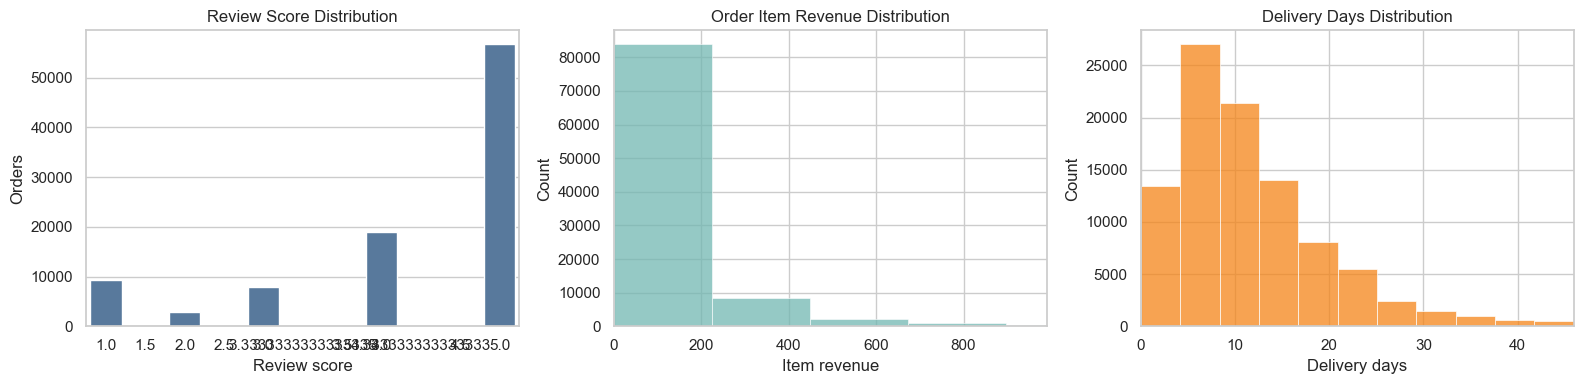

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=model_data, x="review_score", ax=axes[0], color="#4C78A8")
axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Review score")
axes[0].set_ylabel("Orders")

sns.histplot(data=delivered, x="item_revenue", bins=60, ax=axes[1], color="#72B7B2")
axes[1].set_title("Order Item Revenue Distribution")
axes[1].set_xlabel("Item revenue")
axes[1].set_xlim(0, delivered["item_revenue"].quantile(0.99))

sns.histplot(data=delivered, x="delivery_days", bins=50, ax=axes[2], color="#F58518")
axes[2].set_title("Delivery Days Distribution")
axes[2].set_xlabel("Delivery days")
axes[2].set_xlim(0, delivered["delivery_days"].quantile(0.99))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_univariate_eda.png", dpi=160)
plt.show()

## 8. Outlier Analysis

Outliers are expected in ecommerce data because a small number of orders may have unusually high values, large freight costs, or very long delivery times. Instead of deleting them immediately, this EDA identifies them and uses robust summaries and visual scaling where appropriate.

In [162]:
outlier_fields = ["item_revenue", "freight_value", "payment_value", "delivery_days", "payment_installments"]
rows = []
for field in outlier_fields:
    series = delivered[field].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    rows.append(
        {
            "field": field,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(((series < lower) | (series > upper)).sum()),
            "outlier_rate": ((series < lower) | (series > upper)).mean(),
        }
    )

outlier_summary = pd.DataFrame(rows)
outlier_summary

,field,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
0,item_revenue,45.90,149.90,104.00,-110.10,305.90,7659,0.08
1,freight_value,13.85,24.02,10.17,-1.40,39.27,9697,0.10
2,payment_value,61.88,176.33,114.45,-109.80,348.00,7576,0.08
3,delivery_days,6.00,15.00,9.00,-7.50,28.50,5022,0.05
4,payment_installments,1.00,4.00,3.00,-3.50,8.50,6084,0.06


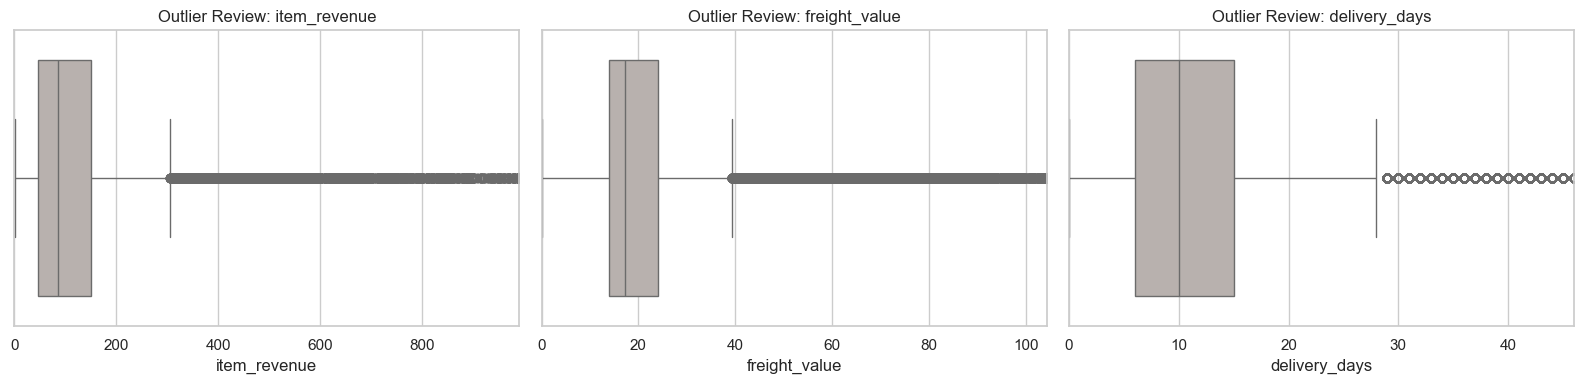

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, field in zip(axes, ["item_revenue", "freight_value", "delivery_days"]):
    sns.boxplot(data=delivered, x=field, ax=ax, color="#BAB0AC")
    ax.set_title(f"Outlier Review: {field}")
    ax.set_xlim(0, delivered[field].quantile(0.99))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_outlier_boxplots.png", dpi=160)
plt.show()

## 9. Bivariate EDA: Revenue, Category, Geography, and Satisfaction

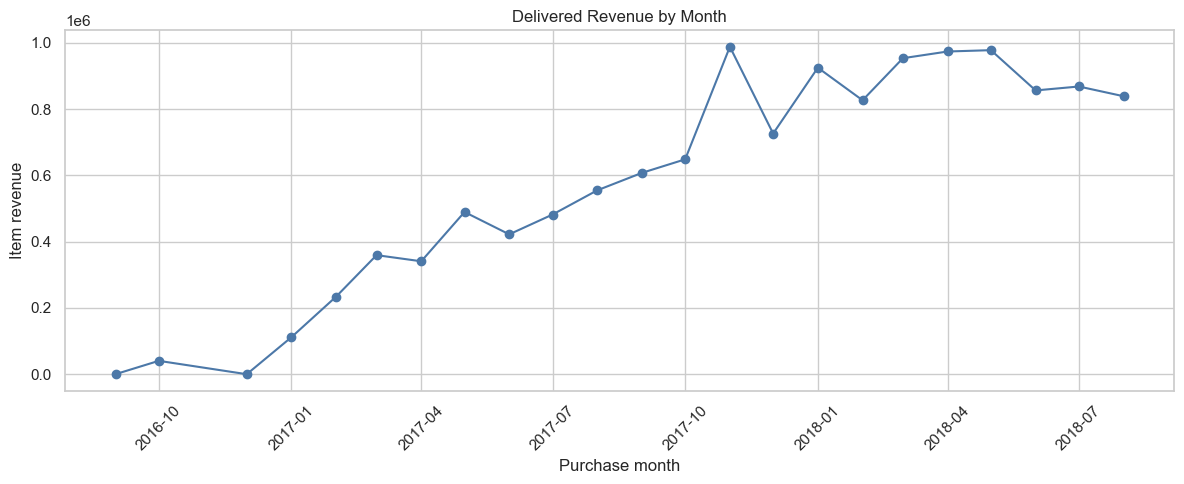

,purchase_month,orders,revenue,low_review_rate
18,2018-04-01,6798,"973,534.09",0.12
19,2018-05-01,6749,"977,544.69",0.11
20,2018-06-01,6099,"856,077.86",0.10
21,2018-07-01,6159,"867,953.46",0.10
22,2018-08-01,6351,"838,576.64",0.10


In [164]:
monthly = (
    delivered.groupby("purchase_month")
    .agg(orders=("order_id", "nunique"), revenue=("item_revenue", "sum"), low_review_rate=("low_review", "mean"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["purchase_month"], monthly["revenue"], marker="o", color="#4C78A8")
ax1.set_title("Delivered Revenue by Month")
ax1.set_xlabel("Purchase month")
ax1.set_ylabel("Item revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_monthly_revenue.png", dpi=160)
plt.show()

monthly.tail()

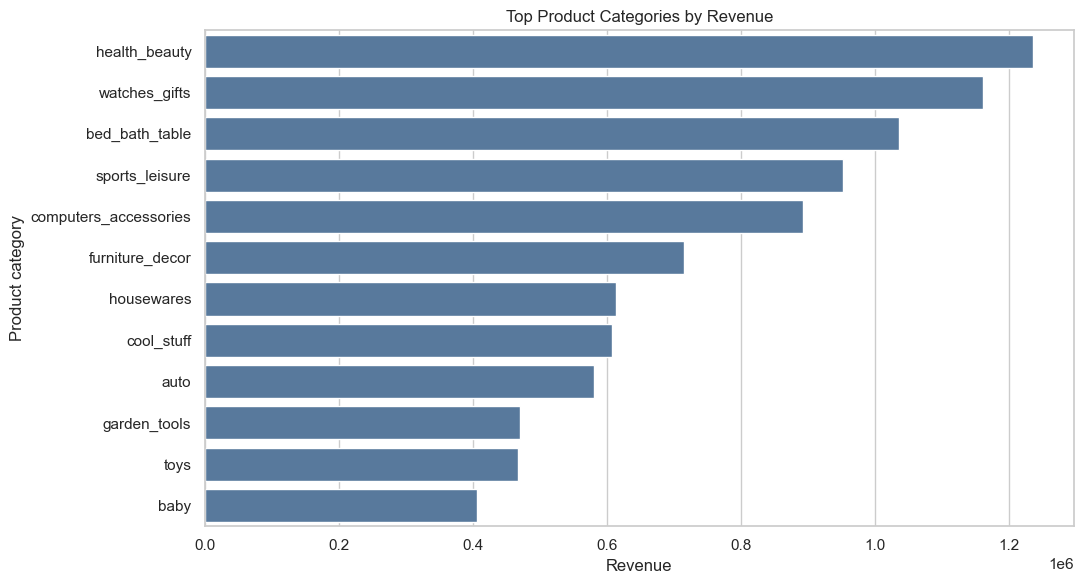

,primary_category,orders,revenue,avg_order_value,low_review_rate
0,health_beauty,8621,"1,234,792.71",143.23,0.11
1,watches_gifts,5455,"1,160,214.09",212.69,0.13
2,bed_bath_table,9240,"1,036,092.78",112.13,0.16
3,sports_leisure,7478,"952,768.94",127.41,0.11
4,computers_accessories,6520,"892,264.23",136.85,0.14
5,furniture_decor,6208,"715,444.83",115.25,0.15
6,housewares,5671,"612,859.07",108.07,0.11
7,cool_stuff,3516,"607,466.01",172.77,0.11
8,auto,3804,"580,935.21",152.72,0.13
9,garden_tools,3411,"470,175.40",137.84,0.12


In [165]:
category_summary = (
    delivered.groupby("primary_category")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum"),
        avg_order_value=("item_revenue", "mean"),
        low_review_rate=("low_review", "mean"),
    )
    .query("orders >= 100")
    .sort_values("revenue", ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=category_summary, y="primary_category", x="revenue", ax=ax, color="#4C78A8")
ax.set_title("Top Product Categories by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("Product category")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_top_categories.png", dpi=160)
plt.show()

category_summary

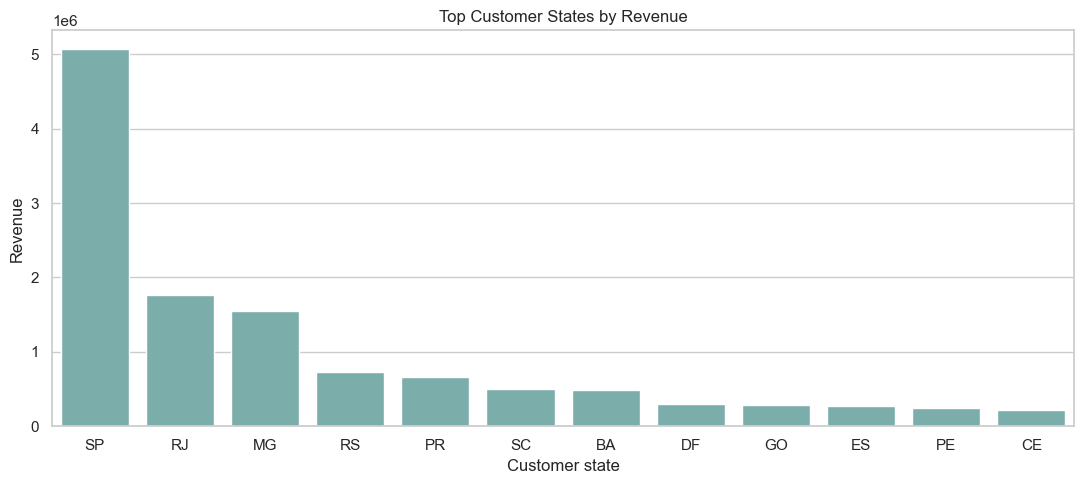

,customer_state,orders,revenue,avg_order_value,low_review_rate
0,SP,40501,"5,067,633.16",125.12,0.11
1,RJ,12350,"1,759,651.13",142.48,0.18
2,MG,11354,"1,552,481.83",136.73,0.12
3,RS,5345,"728,897.47",136.37,0.12
4,PR,4923,"666,063.51",135.30,0.11
5,SC,3546,"507,012.13",142.98,0.13
6,BA,3256,"493,584.14",151.59,0.17
7,DF,2080,"296,498.41",142.55,0.13
8,GO,1957,"282,836.70",144.53,0.13
9,ES,1995,"268,643.45",134.66,0.14


In [166]:
state_summary = (
    delivered.groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum"),
        avg_order_value=("item_revenue", "mean"),
        low_review_rate=("low_review", "mean"),
    )
    .sort_values("revenue", ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=state_summary, x="customer_state", y="revenue", ax=ax, color="#72B7B2")
ax.set_title("Top Customer States by Revenue")
ax.set_xlabel("Customer state")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_top_states.png", dpi=160)
plt.show()

state_summary

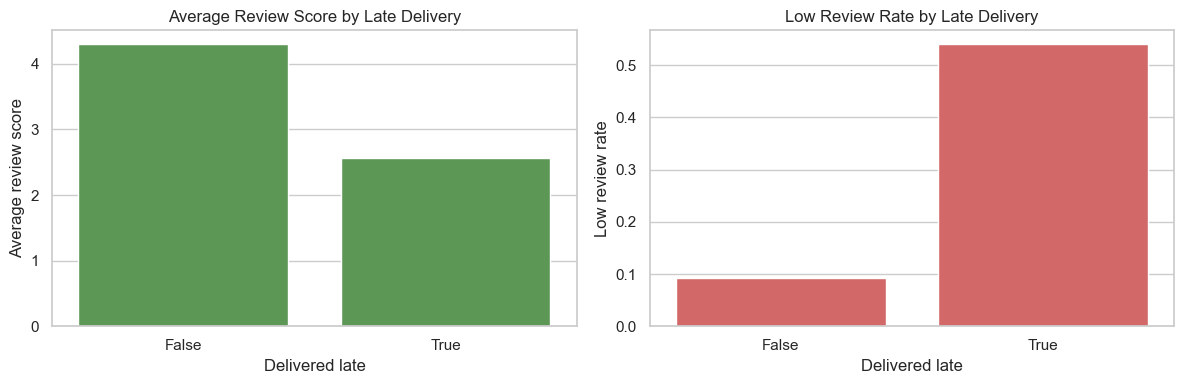

,delivered_late,orders,avg_review_score,low_review_rate
0,False,88171,4.29,0.09
1,True,7661,2.57,0.54


In [167]:
delivery_review = (
    model_data.groupby("delivered_late")
    .agg(orders=("order_id", "nunique"), avg_review_score=("review_score", "mean"), low_review_rate=("low_review", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=delivery_review, x="delivered_late", y="avg_review_score", ax=axes[0], color="#54A24B")
axes[0].set_title("Average Review Score by Late Delivery")
axes[0].set_xlabel("Delivered late")
axes[0].set_ylabel("Average review score")

sns.barplot(data=delivery_review, x="delivered_late", y="low_review_rate", ax=axes[1], color="#E45756")
axes[1].set_title("Low Review Rate by Late Delivery")
axes[1].set_xlabel("Delivered late")
axes[1].set_ylabel("Low review rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_late_delivery_review.png", dpi=160)
plt.show()

delivery_review

### Additional EDA: Product Categories With Higher Satisfaction Risk

Revenue alone does not tell the whole story. The table below focuses on categories with at least 100 delivered orders and ranks them by low-review rate. This helps identify categories that may need quality checks, seller monitoring, delivery improvements, or customer support attention.

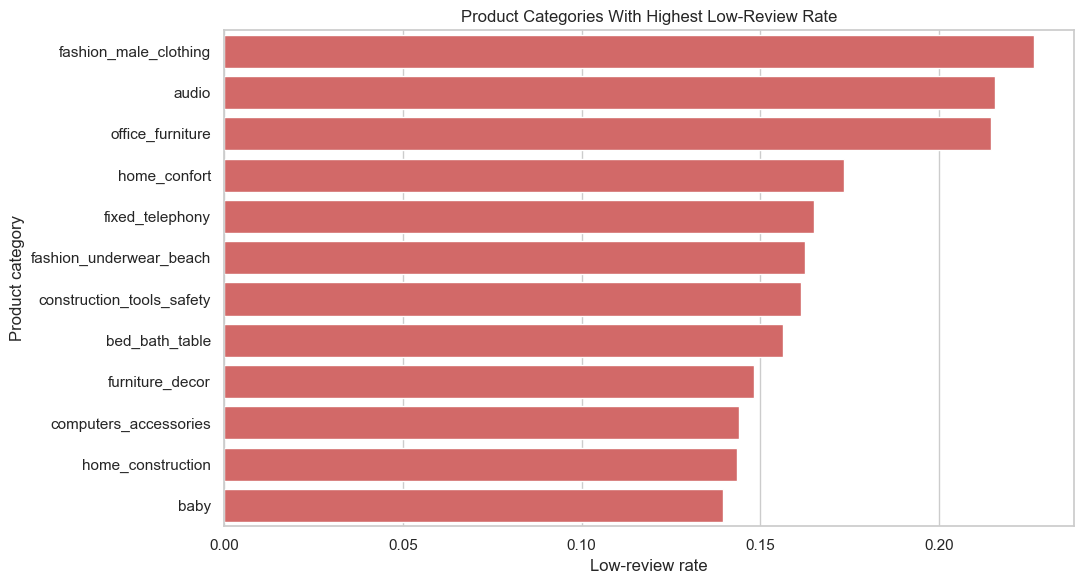

,primary_category,orders,revenue,avg_order_value,avg_delivery_days,late_delivery_rate,low_review_rate
0,fashion_male_clothing,106,"10,452.33",98.61,12.38,0.05,0.23
1,audio,348,"52,157.50",149.88,13.03,0.13,0.22
2,office_furniture,1244,"267,215.34",214.80,20.26,0.09,0.21
3,home_confort,346,"53,403.39",154.35,13.28,0.11,0.17
4,fixed_telephony,212,"55,394.69",261.30,12.08,0.05,0.17
5,fashion_underwear_beach,117,"9,305.95",79.54,13.56,0.13,0.16
6,construction_tools_safety,155,"39,201.11",252.91,11.23,0.05,0.16
7,bed_bath_table,9240,"1,036,092.78",112.13,12.53,0.09,0.16
8,furniture_decor,6208,"715,444.83",115.25,12.64,0.09,0.15
9,computers_accessories,6520,"892,264.23",136.85,12.73,0.08,0.14


In [168]:
category_risk = (
    delivered.groupby("primary_category")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum"),
        avg_order_value=("item_revenue", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("delivered_late", "mean"),
        low_review_rate=("low_review", "mean"),
    )
    .query("orders >= 100")
    .sort_values("low_review_rate", ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=category_risk, y="primary_category", x="low_review_rate", ax=ax, color="#E45756")
ax.set_title("Product Categories With Highest Low-Review Rate")
ax.set_xlabel("Low-review rate")
ax.set_ylabel("Product category")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_category_low_review_risk.png", dpi=160)
plt.show()

category_risk

### Additional EDA: Payment Behavior and Customer Satisfaction

Payment method and installment behavior may reflect customer affordability, product price points, or purchasing patterns. This view checks whether low-review risk varies by the primary payment type.

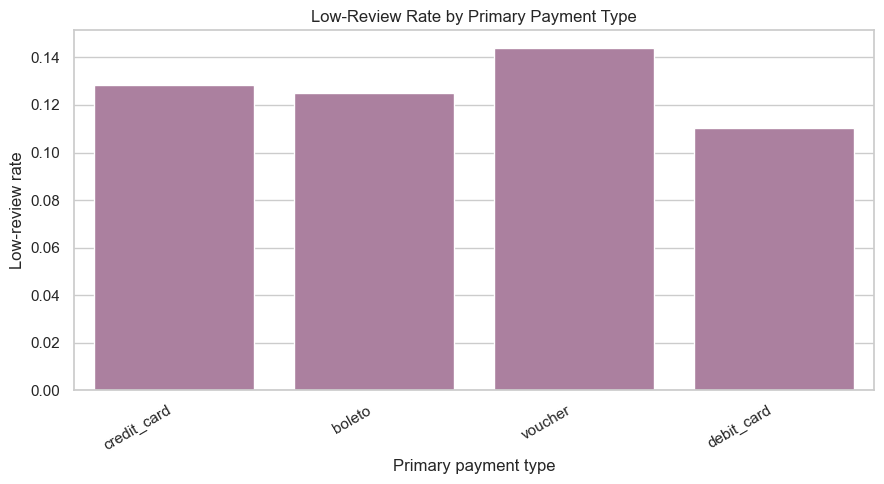

,primary_payment_type,orders,avg_payment_value,avg_installments,low_review_rate
0,credit_card,73446,165.24,3.51,0.13
1,boleto,19062,143.84,1.00,0.13
2,voucher,1845,112.80,1.12,0.14
3,debit_card,1478,140.64,1.00,0.11


In [169]:
payment_review = (
    model_data.groupby("primary_payment_type")
    .agg(
        orders=("order_id", "nunique"),
        avg_payment_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean"),
        low_review_rate=("low_review", "mean"),
    )
    .sort_values("orders", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=payment_review, x="primary_payment_type", y="low_review_rate", ax=ax, color="#B279A2")
ax.set_title("Low-Review Rate by Primary Payment Type")
ax.set_xlabel("Primary payment type")
ax.set_ylabel("Low-review rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_payment_low_review.png", dpi=160)
plt.show()

payment_review

### Additional EDA: Freight Burden

Freight cost can affect customer perception of value. This feature compares freight cost to item revenue. A high freight-to-item ratio may indicate orders where shipping cost feels expensive relative to the product.

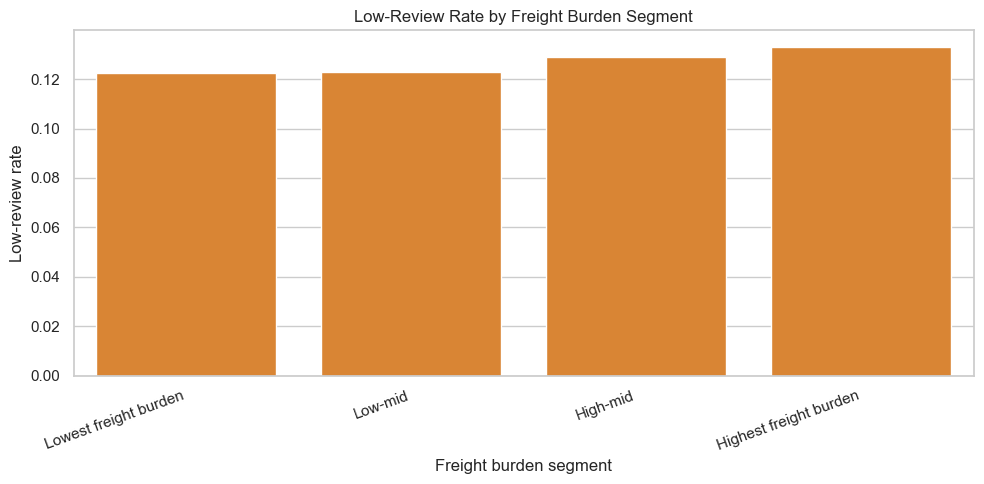

,freight_burden_segment,orders,avg_freight_ratio,avg_order_value,avg_review_score,low_review_rate
0,Lowest freight burden,24119,0.08,296.98,4.20,0.12
1,Low-mid,24119,0.18,123.50,4.16,0.12
2,High-mid,24119,0.29,82.94,4.15,0.13
3,Highest freight burden,24119,0.68,44.76,4.11,0.13


In [170]:
delivered = delivered.copy()
delivered["freight_to_item_ratio"] = delivered["freight_value"] / delivered["item_revenue"]
delivered.loc[~delivered["freight_to_item_ratio"].between(0, 10), "freight_to_item_ratio"] = pd.NA

freight_bins = pd.qcut(
    delivered["freight_to_item_ratio"].rank(method="first"),
    4,
    labels=["Lowest freight burden", "Low-mid", "High-mid", "Highest freight burden"],
)
delivered["freight_burden_segment"] = freight_bins

freight_burden = (
    delivered.groupby("freight_burden_segment", observed=True)
    .agg(
        orders=("order_id", "nunique"),
        avg_freight_ratio=("freight_to_item_ratio", "mean"),
        avg_order_value=("item_revenue", "mean"),
        avg_review_score=("review_score", "mean"),
        low_review_rate=("low_review", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=freight_burden, x="freight_burden_segment", y="low_review_rate", ax=ax, color="#F58518")
ax.set_title("Low-Review Rate by Freight Burden Segment")
ax.set_xlabel("Freight burden segment")
ax.set_ylabel("Low-review rate")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_freight_burden.png", dpi=160)
plt.show()

freight_burden

### Additional EDA: Correlation Review for Numeric Features

This correlation matrix helps identify relationships among engineered numeric variables before modeling. It is not a substitute for model interpretation, but it is useful for spotting redundant variables and possible drivers of customer satisfaction risk.

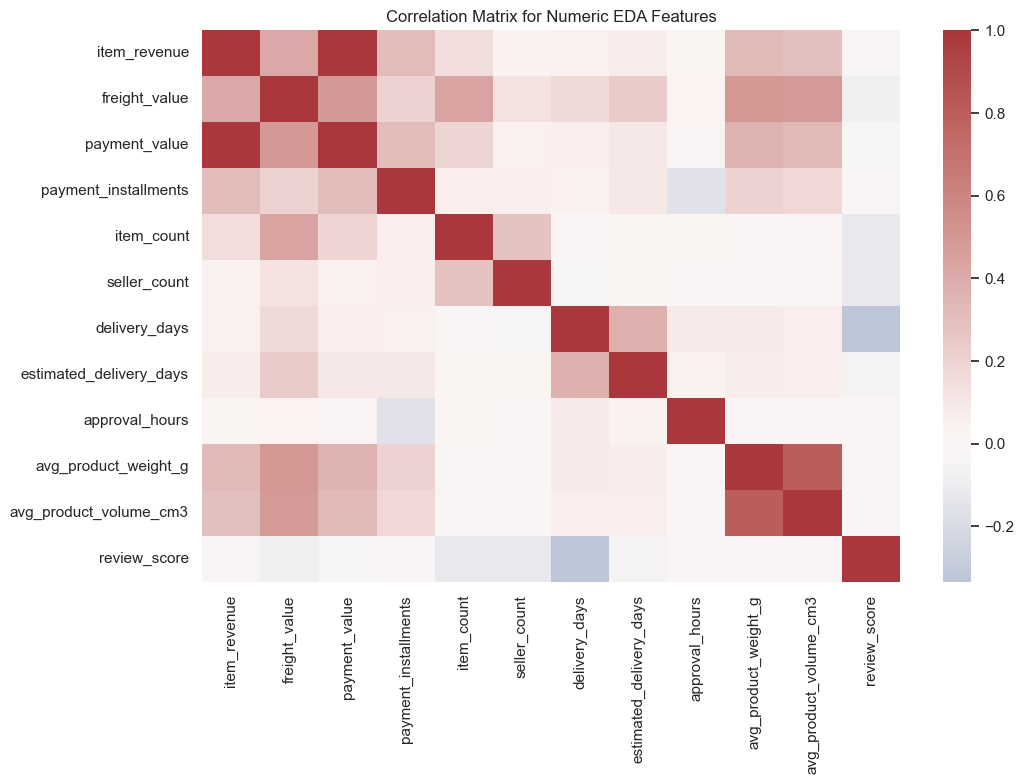

,review_score
delivery_days,-0.33
item_count,-0.12
seller_count,-0.12
freight_value,-0.09
estimated_delivery_days,-0.05
payment_value,-0.04
item_revenue,-0.03
payment_installments,-0.03
avg_product_weight_g,-0.03
avg_product_volume_cm3,-0.02


In [171]:
corr_fields = [
    "item_revenue",
    "freight_value",
    "payment_value",
    "payment_installments",
    "item_count",
    "seller_count",
    "delivery_days",
    "estimated_delivery_days",
    "approval_hours",
    "avg_product_weight_g",
    "avg_product_volume_cm3",
    "review_score",
]

corr_matrix = model_data[corr_fields].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap="vlag", center=0, annot=False, ax=ax)
ax.set_title("Correlation Matrix for Numeric EDA Features")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_numeric_correlation.png", dpi=160)
plt.show()

corr_matrix[["review_score"]].sort_values("review_score")

### EDA Observations From Section 9

- Revenue concentration by state and category suggests that business interventions should be prioritized rather than spread evenly across the marketplace.
- Delivery lateness is strongly associated with low review scores, which supports using delivery features in the baseline model.
- Categories with elevated low-review rates should be investigated for seller quality, product quality, shipping complexity, or expectation mismatch.
- Payment behavior and freight burden provide additional context about customer experience and perceived value.
- Correlation analysis helps guide feature selection, but the baseline model is needed to evaluate combined predictive signal.

## 10. Customer-Level Feature Engineering and Segmentation

This section creates RFM features to support the retention and customer segmentation part of the capstone.

In [172]:
customer_rfm = (
    delivered.groupby("customer_unique_id")
    .agg(
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary_value=("item_revenue", "sum"),
        avg_order_value=("item_revenue", "mean"),
        avg_review_score=("review_score", "mean"),
        home_state=("customer_state", lambda x: x.mode().iat[0] if not x.mode().empty else None),
    )
    .reset_index()
)

snapshot_date = delivered["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
customer_rfm["recency_days"] = (snapshot_date - customer_rfm["last_purchase"]).dt.days
customer_rfm["is_repeat_customer"] = customer_rfm["frequency"] > 1

customer_rfm["recency_score"] = pd.qcut(customer_rfm["recency_days"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
customer_rfm["frequency_score"] = pd.qcut(customer_rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
customer_rfm["monetary_score"] = pd.qcut(customer_rfm["monetary_value"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
customer_rfm["rfm_score"] = customer_rfm["recency_score"] + customer_rfm["frequency_score"] + customer_rfm["monetary_score"]

def assign_segment(row):
    if row["rfm_score"] >= 10 and row["monetary_score"] >= 3:
        return "High-value active"
    if row["recency_score"] <= 2 and row["monetary_score"] >= 3:
        return "High-value at risk"
    if row["frequency_score"] >= 3:
        return "Repeat buyers"
    if row["recency_score"] >= 3:
        return "Recent low-value"
    return "Low engagement"

customer_rfm["segment"] = customer_rfm.apply(assign_segment, axis=1)

segment_profile = (
    customer_rfm.groupby("segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary_value=("monetary_value", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        repeat_customer_rate=("is_repeat_customer", "mean"),
    )
    .sort_values("avg_monetary_value", ascending=False)
    .reset_index()
)
segment_profile

,segment,customers,avg_recency_days,avg_frequency,avg_monetary_value,avg_order_value,repeat_customer_rate
0,High-value active,13643,120.99,1.14,279.04,257.80,0.13
1,High-value at risk,21446,370.56,1.03,227.81,224.09,0.03
2,Recent low-value,21949,115.29,1.00,123.23,123.23,0.00
3,Repeat buyers,24345,234.49,1.02,51.70,51.11,0.02
4,Low engagement,11975,365.49,1.00,47.21,47.21,0.00


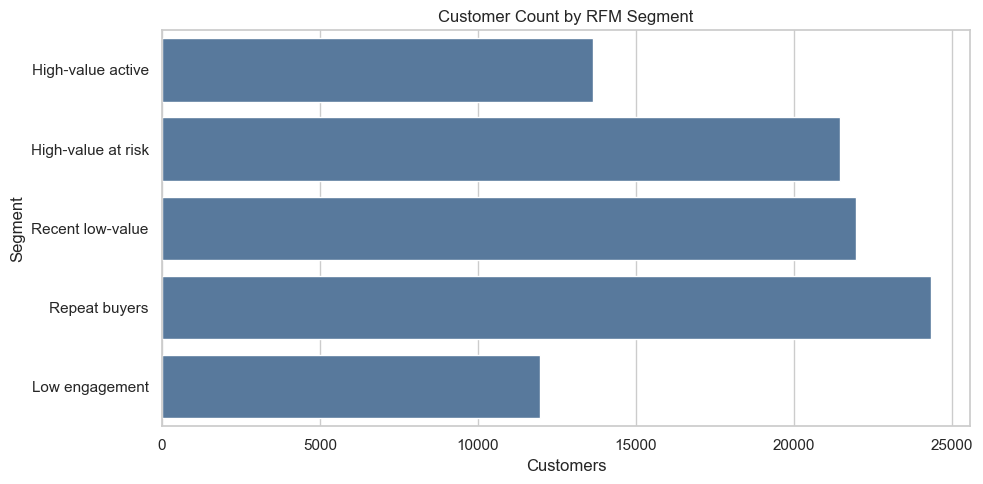

In [173]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=segment_profile, y="segment", x="customers", ax=ax, color="#4C78A8")
ax.set_title("Customer Count by RFM Segment")
ax.set_xlabel("Customers")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_rfm_segments.png", dpi=160)
plt.show()

## 11. Baseline Machine Learning Model

### Modeling Goal

Develop a baseline classification model that predicts whether an order will receive a low review score, defined as review score 1 or 2.

### Why Logistic Regression?

Logistic regression is a strong baseline because it is simple, fast, interpretable, and appropriate for binary classification. Later modules can compare more complex models, such as random forest or gradient boosting, against this baseline.

### Evaluation Metric

The main metric is **ROC-AUC**, because the target is imbalanced and ROC-AUC measures the model's ability to rank low-review orders above non-low-review orders across thresholds. Precision, recall, and F1-score are also reviewed because the business needs to understand the tradeoff between catching bad experiences and creating false alarms.

In [174]:
features = [
    "item_revenue",
    "freight_value",
    "item_count",
    "seller_count",
    "payment_value",
    "payment_installments",
    "payment_types",
    "delivery_days",
    "estimated_delivery_days",
    "approval_hours",
    "delivered_late",
    "purchase_month_num",
    "purchase_dayofweek",
    "avg_product_weight_g",
    "avg_product_volume_cm3",
    "customer_state",
    "primary_category",
    "primary_payment_type",
]

target = "low_review"

baseline_df = model_data[features + [target]].copy()
baseline_df[target] = baseline_df[target].astype(int)

X = baseline_df[features]
y = baseline_df[target]

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=25)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=42),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Baseline ROC-AUC: {roc_auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["Not low review", "Low review"]))

Baseline ROC-AUC: 0.753
                precision    recall  f1-score   support

Not low review       0.93      0.85      0.89     20899
    Low review       0.35      0.55      0.43      3059

      accuracy                           0.81     23958
     macro avg       0.64      0.70      0.66     23958
  weighted avg       0.85      0.81      0.83     23958



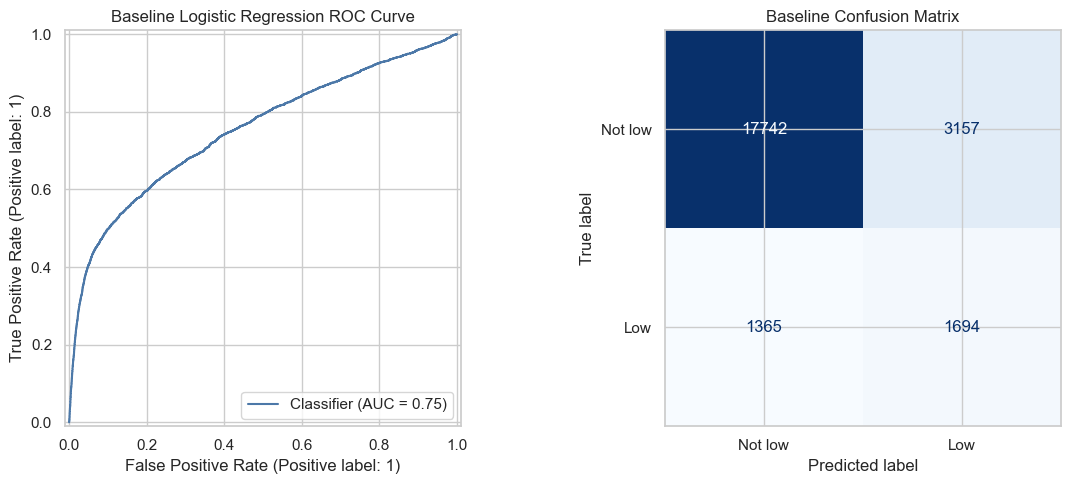

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], color="#4C78A8")
axes[0].set_title("Baseline Logistic Regression ROC Curve")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not low", "Low"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Baseline Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_baseline_model.png", dpi=160)
plt.show()

## 12. Boosting Model Comparison

The rubric requires one baseline model, but testing a boosting model is useful because boosted trees can capture nonlinear relationships and interactions between delivery, payment, product, and geography features.

This section compares the logistic regression baseline against a **Histogram Gradient Boosting Classifier**. The same train/test split and feature set are used for a fair comparison. A random forest comparison and final model selection are added in later sections.

In [176]:
boosting_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=25)),
    ]
)

boosting_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", boosting_categorical_transformer, categorical_features),
    ]
)

boosting_model = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=160,
                max_leaf_nodes=31,
                l2_regularization=0.05,
                random_state=42,
            ),
        ),
    ]
)

boosting_model.fit(X_train, y_train)
boost_pred = boosting_model.predict(X_test)
boost_proba = boosting_model.predict_proba(X_test)[:, 1]

boost_roc_auc = roc_auc_score(y_test, boost_proba)
print(f"Boosting ROC-AUC: {boost_roc_auc:.3f}")
print(classification_report(y_test, boost_pred, target_names=["Not low review", "Low review"]))

Boosting ROC-AUC: 0.761
                precision    recall  f1-score   support

Not low review       0.91      0.98      0.94     20899
    Low review       0.73      0.30      0.42      3059

      accuracy                           0.90     23958
     macro avg       0.82      0.64      0.68     23958
  weighted avg       0.88      0.90      0.88     23958



In [177]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Logistic Regression Baseline",
            "roc_auc": roc_auc_score(y_test, y_proba),
            "accuracy": (y_pred == y_test).mean(),
            "low_review_recall": classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
            "low_review_precision": classification_report(y_test, y_pred, output_dict=True)["1"]["precision"],
            "low_review_f1": classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"],
        },
        {
            "model": "Histogram Gradient Boosting",
            "roc_auc": boost_roc_auc,
            "accuracy": (boost_pred == y_test).mean(),
            "low_review_recall": classification_report(y_test, boost_pred, output_dict=True)["1"]["recall"],
            "low_review_precision": classification_report(y_test, boost_pred, output_dict=True)["1"]["precision"],
            "low_review_f1": classification_report(y_test, boost_pred, output_dict=True)["1"]["f1-score"],
        },
    ]
)

model_comparison

,model,roc_auc,accuracy,low_review_recall,low_review_precision,low_review_f1
0,Logistic Regression Baseline,0.75,0.81,0.55,0.35,0.43
1,Histogram Gradient Boosting,0.76,0.90,0.30,0.73,0.42


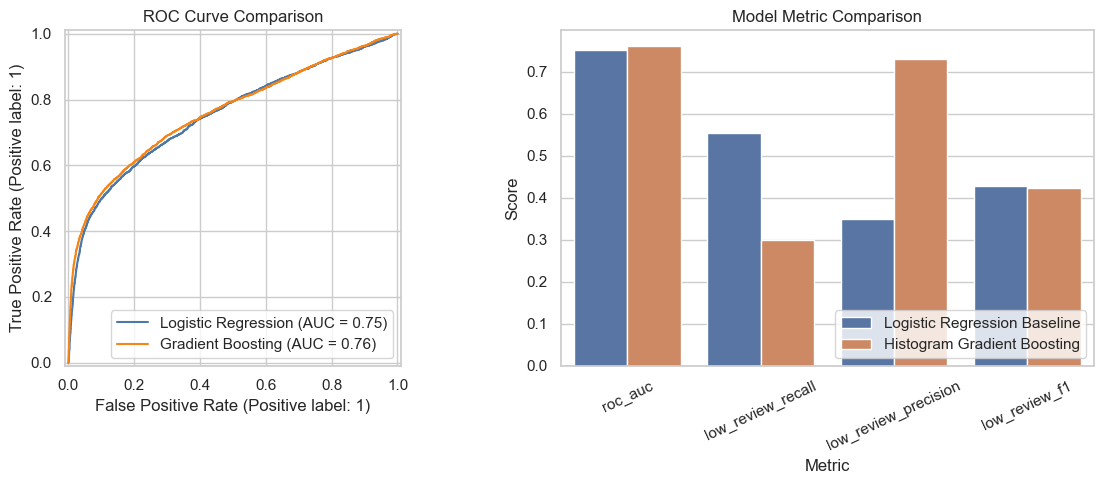

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], color="#4C78A8", name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, boost_proba, ax=axes[0], color="#F58518", name="Gradient Boosting")
axes[0].set_title("ROC Curve Comparison")

comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["roc_auc", "low_review_recall", "low_review_precision", "low_review_f1"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=comparison_melted, x="metric", y="score", hue="model", ax=axes[1])
axes[1].set_title("Model Metric Comparison")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_boosting_comparison.png", dpi=160)
plt.show()

### Boosting Model Interpretation

The boosting model is expected to improve ranking performance if there are nonlinear patterns or interactions in the engineered features. The comparison should be interpreted using both ROC-AUC and low-review recall:

- **ROC-AUC** shows how well the model ranks risky orders above non-risky orders.
- **Recall for low reviews** shows how many poor experiences the model catches.
- **Precision for low reviews** shows how many flagged orders are actually low-review orders.

If boosting improves ROC-AUC but reduces recall, the business may still prefer the logistic regression threshold or may tune the boosting threshold later. The best model depends on whether the business wants to catch as many poor experiences as possible or reduce false alerts.

## 13. Random Forest Model Comparison

Random forest is another useful comparison model because it can capture nonlinear patterns and feature interactions while remaining easier to explain than some boosting methods. This model uses the same feature set and train/test split.

In [179]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=14,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)
forest_proba = forest_model.predict_proba(X_test)[:, 1]

forest_roc_auc = roc_auc_score(y_test, forest_proba)
print(f"Random Forest ROC-AUC: {forest_roc_auc:.3f}")
print(classification_report(y_test, forest_pred, target_names=["Not low review", "Low review"]))

Random Forest ROC-AUC: 0.756
                precision    recall  f1-score   support

Not low review       0.93      0.86      0.89     20899
    Low review       0.37      0.55      0.44      3059

      accuracy                           0.82     23958
     macro avg       0.65      0.71      0.67     23958
  weighted avg       0.86      0.82      0.84     23958



## 14. Model Comparison and Selection

Because the business goal is to identify poor customer experiences early, the best model should not be chosen by accuracy alone. Accuracy can be misleading when most orders are not low-review orders.

For this project, the most important metrics are:

- **ROC-AUC:** ranking ability across thresholds.
- **Low-review recall:** how many poor experiences the model catches.
- **Low-review precision:** how often high-risk flags are correct.
- **Low-review F1:** balance between precision and recall.

The table below compares all tested models using the default classification threshold.

In [180]:
def model_metrics(name, y_true, y_hat, y_score):
    report = classification_report(y_true, y_hat, output_dict=True, zero_division=0)
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_true, y_score),
        "accuracy": (y_hat == y_true).mean(),
        "low_review_precision": report["1"]["precision"],
        "low_review_recall": report["1"]["recall"],
        "low_review_f1": report["1"]["f1-score"],
    }

model_comparison = pd.DataFrame(
    [
        model_metrics("Logistic Regression", y_test, y_pred, y_proba),
        model_metrics("Random Forest", y_test, forest_pred, forest_proba),
        model_metrics("Histogram Gradient Boosting", y_test, boost_pred, boost_proba),
    ]
).sort_values("roc_auc", ascending=False)

model_comparison

,model,roc_auc,accuracy,low_review_precision,low_review_recall,low_review_f1
2,Histogram Gradient Boosting,0.76,0.90,0.73,0.30,0.42
1,Random Forest,0.76,0.82,0.37,0.55,0.44
0,Logistic Regression,0.75,0.81,0.35,0.55,0.43


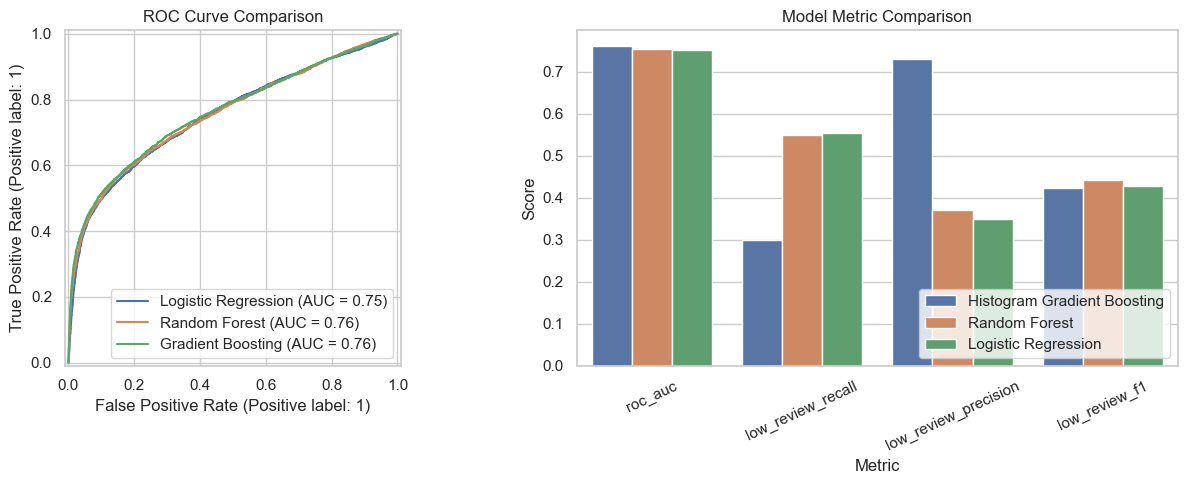

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, forest_proba, ax=axes[0], name="Random Forest")
RocCurveDisplay.from_predictions(y_test, boost_proba, ax=axes[0], name="Gradient Boosting")
axes[0].set_title("ROC Curve Comparison")

comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["roc_auc", "low_review_recall", "low_review_precision", "low_review_f1"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=comparison_melted, x="metric", y="score", hue="model", ax=axes[1])
axes[1].set_title("Model Metric Comparison")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_multi_model_comparison.png", dpi=160)
plt.show()

## 15. Threshold Tuning for the Best-Ranking Model

The default probability threshold is 0.50. That threshold is often not ideal for an imbalanced business problem. If the business wants to catch more low-review orders, it can lower the threshold and accept more false positives.

This section evaluates thresholds for the model with the strongest ROC-AUC.

In [182]:
best_row = model_comparison.sort_values("roc_auc", ascending=False).iloc[0]
best_model_name = best_row["model"]

score_lookup = {
    "Logistic Regression": y_proba,
    "Random Forest": forest_proba,
    "Histogram Gradient Boosting": boost_proba,
}
best_scores = score_lookup[best_model_name]

threshold_rows = []
for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    threshold_pred = (best_scores >= threshold).astype(int)
    report = classification_report(y_test, threshold_pred, output_dict=True, zero_division=0)
    threshold_rows.append(
        {
            "model": best_model_name,
            "threshold": threshold,
            "accuracy": (threshold_pred == y_test).mean(),
            "low_review_precision": report["1"]["precision"],
            "low_review_recall": report["1"]["recall"],
            "low_review_f1": report["1"]["f1-score"],
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

,model,threshold,accuracy,low_review_precision,low_review_recall,low_review_f1
0,Histogram Gradient Boosting,0.20,0.86,0.47,0.49,0.48
1,Histogram Gradient Boosting,0.25,0.88,0.53,0.44,0.48
2,Histogram Gradient Boosting,0.30,0.89,0.59,0.40,0.48
3,Histogram Gradient Boosting,0.35,0.89,0.63,0.37,0.47
4,Histogram Gradient Boosting,0.40,0.89,0.67,0.35,0.46
5,Histogram Gradient Boosting,0.45,0.90,0.70,0.32,0.44
6,Histogram Gradient Boosting,0.50,0.90,0.73,0.30,0.42


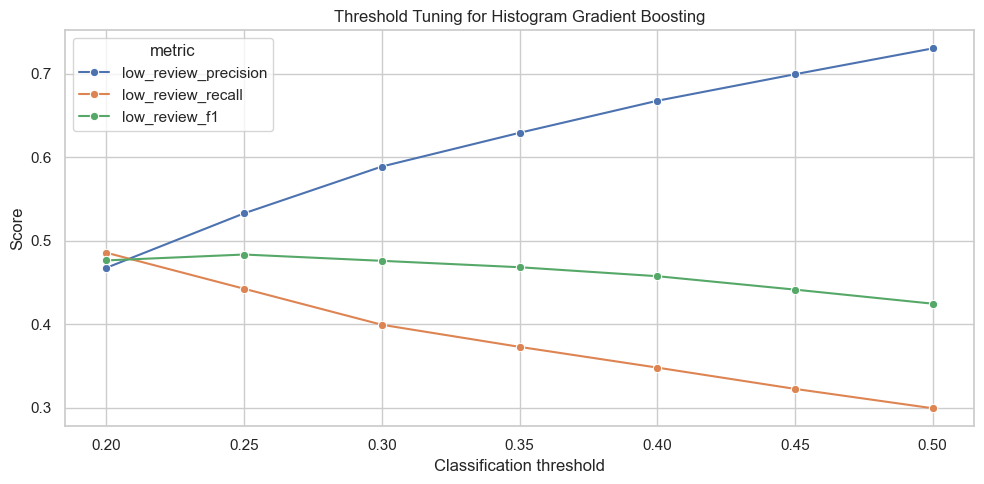

In [183]:
fig, ax = plt.subplots(figsize=(10, 5))
threshold_plot = threshold_results.melt(
    id_vars="threshold",
    value_vars=["low_review_precision", "low_review_recall", "low_review_f1"],
    var_name="metric",
    value_name="score",
)
sns.lineplot(data=threshold_plot, x="threshold", y="score", hue="metric", marker="o", ax=ax)
ax.set_title(f"Threshold Tuning for {best_model_name}")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "module20_threshold_tuning.png", dpi=160)
plt.show()

## 16. Final Model Choice

The best model depends on the business priority:

- If the business wants the best overall risk ranking, choose the model with the highest ROC-AUC.
- If the business wants to catch the largest number of poor experiences, prioritize low-review recall.
- If the business wants fewer false alerts, prioritize low-review precision.

For this capstone, the recommended selection is the model with the strongest ROC-AUC, then tune its threshold based on business capacity for proactive support.

In [184]:
best_default_model = model_comparison.sort_values("roc_auc", ascending=False).iloc[0]
best_threshold_row = threshold_results.sort_values("low_review_f1", ascending=False).iloc[0]

selection_summary = pd.DataFrame(
    [
        {
            "selection_type": "Best default ranking model",
            "model": best_default_model["model"],
            "threshold": 0.50,
            "roc_auc": best_default_model["roc_auc"],
            "low_review_precision": best_default_model["low_review_precision"],
            "low_review_recall": best_default_model["low_review_recall"],
            "low_review_f1": best_default_model["low_review_f1"],
        },
        {
            "selection_type": "Best F1 threshold for selected model",
            "model": best_model_name,
            "threshold": best_threshold_row["threshold"],
            "roc_auc": best_default_model["roc_auc"],
            "low_review_precision": best_threshold_row["low_review_precision"],
            "low_review_recall": best_threshold_row["low_review_recall"],
            "low_review_f1": best_threshold_row["low_review_f1"],
        },
    ]
)

selection_summary

,selection_type,model,threshold,roc_auc,low_review_precision,low_review_recall,low_review_f1
0,Best default ranking model,Histogram Gradient Boosting,0.50,0.76,0.73,0.30,0.42
1,Best F1 threshold for selected model,Histogram Gradient Boosting,0.25,0.76,0.53,0.44,0.48


## 17. Baseline Model Interpretation

The baseline model is not intended to be the final model. Its purpose is to establish a comparison point for Module 24.

A useful baseline should show whether the engineered features contain signal about low customer satisfaction. If ROC-AUC is above 0.50, the model is ranking low-review orders better than random chance. If recall for the low-review class is reasonably high, the model may be useful for identifying orders that deserve proactive support, though precision must also be considered to avoid overwhelming support teams with false alarms.

Because this is an initial EDA assignment, the next phase should compare this model against tree-based models and evaluate feature importance.

## 18. Expanded Analysis Observations

### What the EDA Reveals

1. **Customer satisfaction is measurable and actionable.** Review score provides a clear target for identifying poor customer experiences.
2. **Delivery performance matters.** Late deliveries have much lower average review scores than on-time or early deliveries.
3. **Revenue is not evenly distributed.** A small set of states and product categories produce a large share of revenue, which creates clear prioritization opportunities.
4. **Repeat purchase behavior is limited.** The low repeat-customer rate suggests that retention is a meaningful business challenge.
5. **Order economics vary widely.** Order value, freight value, and delivery time all show outliers, which is common in ecommerce and should be handled carefully rather than blindly removed.
6. **A baseline ML model is justified.** The logistic regression model performs better than random guessing, showing that the engineered features contain useful signal.

### Business Actions Suggested by the EDA

- Prioritize proactive support for orders that are late or at high risk of low satisfaction.
- Investigate high-revenue categories and states separately from low-volume categories and regions.
- Use RFM segments to separate high-value active customers from high-value at-risk customers.
- Use the baseline model as a comparison point for more advanced models in the next module.
- Avoid overclaiming true dynamic pricing or conversion optimization because the Olist dataset does not include competitor pricing, inventory, browsing sessions, or cart events.

## 19. Executive Brief: Technical Findings

1. The dataset is large enough for meaningful analysis, with about 100,000 orders and strong coverage of orders, payments, items, customers, sellers, and reviews.
2. Repeat purchase behavior is low, which makes retention a meaningful business problem.
3. Revenue is concentrated by geography and category, especially in the largest customer states and top product categories.
4. Late delivery is strongly associated with lower review scores, making delivery performance an important business lever.
5. The low-review target is imbalanced but usable for classification.
6. The logistic regression baseline provides a comparison point for future models.
7. The next modeling phase should test random forest and gradient boosting, compare performance against this baseline, and translate feature importance into operational recommendations.